# Melting Point 예측 — v4_ann
5인 전문가 합의 파이프라인: VarianceThreshold + Mixup + MI top-300 + Residual MLP (LayerNorm + Swish) + 3-seed Snapshot Ensemble

**목표**: Test R² 0.58 → 0.70~0.75, CV-Test 갭 0.124 → ≤ 0.08, 노트북 전체 실행 ≤ 30분

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn rdkit torch -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, time
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from rdkit import Chem
from rdkit.Chem import Descriptors, MACCSkeys
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import platform, subprocess
if platform.system() == 'Linux':
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    import matplotlib.font_manager as fm
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams["font.family"] = "NanumGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T0 = time.time()
print("라이브러리 로드 완료")
print(f"디바이스: {DEVICE}")

라이브러리 로드 완료
디바이스: cpu


## 1. 데이터 로드

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/sunghee-sketch/middle-test/main/data/Melting_point_2.csv")
df = df.drop_duplicates().reset_index(drop=True)
df = df[df["MP"] >= 0].reset_index(drop=True)
df["MP_log"] = np.log1p(df["MP"])
print(f"데이터 크기: {df.shape}")
print(f"MP 범위: {df['MP'].min():.1f} ~ {df['MP'].max():.1f} K")
df.head()

데이터 크기: (2117, 3)
MP 범위: 13.9 ~ 1870.0 K


,SMILES,MP,MP_log
0,CCN(O)CC,247.650,5.516046
1,c1(C(C)=C)ccccc1,249.950,5.525254
2,C/C=C/CCCC,164.000,5.105945
3,c1(CC)cc(CC)cc(CC)c1,206.735,5.336263
4,COC(C)(C)C(=O)OC,229.600,5.440685


## 2. 피처 추출 (Morgan + MACCS + RDKit)
v3와 동일한 2431차원 피처 추출. 다음 단계에서 VarianceThreshold + MI로 축소합니다.

In [4]:
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)
desc_list  = [(n, f) for n, f in Descriptors.descList if not n.startswith("Ipc")]

def smiles_to_features(smiles_list):
    records, valid_idx = [], []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        morgan = morgan_gen.GetFingerprintAsNumPy(mol).astype(np.float32)
        maccs  = np.array(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32)
        descs  = []
        for _, func in desc_list:
            try:
                v = func(mol)
                descs.append(float(v) if (v is not None and np.isfinite(v)) else 0.0)
            except Exception:
                descs.append(0.0)
        records.append(np.concatenate([morgan, maccs, np.array(descs, np.float32)]))
        valid_idx.append(i)
    X = np.array(records, dtype=np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, valid_idx

print("피처 추출 중...")
t = time.time()
X_all, valid_idx = smiles_to_features(df["SMILES"].tolist())
y_all     = df["MP"].values[valid_idx]
y_all_log = df["MP_log"].values[valid_idx]
print(f"유효 샘플: {len(valid_idx)} / {len(df)}  |  피처 차원: {X_all.shape[1]}  |  소요: {time.time()-t:.1f}s")

피처 추출 중...
유효 샘플: 2117 / 2117  |  피처 차원: 2431  |  소요: 7.7s


## 3. Step A — VarianceThreshold (sample-independent 사전 정리)
feature-expert 제안: 분산 ≤ 0.01인 비트는 거의 항상 동일값 → 정보량 0. train/test 분할 전 적용 가능.

In [5]:
vt = VarianceThreshold(threshold=0.01)
X_all_vt = vt.fit_transform(X_all).astype(np.float32)
print(f"VarianceThreshold 전: {X_all.shape[1]} → 후: {X_all_vt.shape[1]} (제거: {X_all.shape[1] - X_all_vt.shape[1]})")

VarianceThreshold 전: 2431 → 후: 504 (제거: 1927)


## 4. Train/Test 분할 + 스케일링

In [6]:
mp_bins = pd.qcut(y_all, q=10, labels=False, duplicates="drop")
X_train, X_test, y_train, y_test, y_tr_log, y_te_log = train_test_split(
    X_all_vt, y_all, y_all_log,
    test_size=0.2, random_state=RANDOM_STATE, stratify=mp_bins
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)
X_train_sc = np.nan_to_num(X_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
X_test_sc  = np.nan_to_num(X_test_sc,  nan=0.0, posinf=0.0, neginf=0.0)
X_train_sc = np.clip(X_train_sc, -10.0, 10.0).astype(np.float32)
X_test_sc  = np.clip(X_test_sc,  -10.0, 10.0).astype(np.float32)

y_tr_log = y_tr_log.astype(np.float32)
y_te_log = y_te_log.astype(np.float32)

high_thr = np.percentile(y_train, 90)
sw_train = np.where(y_train >= high_thr, 3.0, 1.0).astype(np.float32)

print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")

Train: (1693, 504)  |  Test: (424, 504)


## 5. Step 2 — Mutual Information 기반 피처 선별 (top-300)
feature-expert 제안: SHAP 대비 5~10배 빠르고 학습 전 직접 계산 가능. **train fold만 fit** — 누수 방지.

In [7]:
TOP_K = 300
print("MI 계산 중 (1~2분)...")
t = time.time()
mi = mutual_info_regression(X_train_sc, y_tr_log, random_state=RANDOM_STATE, n_neighbors=3)
top_idx = np.argsort(mi)[::-1][:TOP_K]
X_train_sel = X_train_sc[:, top_idx]
X_test_sel  = X_test_sc[:,  top_idx]
print(f"MI top-{TOP_K} 선별 완료 — 소요: {time.time()-t:.1f}s")
print(f"선별 후 Train: {X_train_sel.shape}  |  Test: {X_test_sel.shape}")
print(f"MI 상위 5 평균: {mi[top_idx[:5]].mean():.4f}  |  하위 5 평균: {mi[top_idx[-5:]].mean():.4f}")

MI 계산 중 (1~2분)...
MI top-300 선별 완료 — 소요: 1.6s
선별 후 Train: (1693, 300)  |  Test: (424, 300)
MI 상위 5 평균: 0.2790  |  하위 5 평균: 0.1216


## 6. 모델 정의 — Residual MLP + LayerNorm + Swish, Mixup
architecture-expert 제안: ResidualBlock×3, hidden=256(데이터 작음 고려), Swish(SiLU). augmentation-expert 제안: Mixup α=0.3.

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.ln1 = nn.LayerNorm(dim)
        self.ln2 = nn.LayerNorm(dim)
        self.act = nn.SiLU()
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        h = self.drop(self.act(self.ln1(self.fc1(x))))
        h = self.ln2(self.fc2(h))
        return x + h  # architecture-expert: skip 직후 act 제거 (distribution shift 방지)

class ResidualMLP(nn.Module):
    def __init__(self, input_dim, hidden=256, n_blocks=3, dropout=0.3):
        super().__init__()
        self.proj = nn.Linear(input_dim, hidden)
        self.blocks = nn.ModuleList([ResidualBlock(hidden, dropout) for _ in range(n_blocks)])
        self.head = nn.Sequential(
            nn.LayerNorm(hidden),  # architecture-expert: head 입력 정규화 추가
            nn.Linear(hidden, 64), nn.SiLU(), nn.Linear(64, 1)
        )
    def forward(self, x):
        x = self.proj(x)
        for b in self.blocks:
            x = b(x)
        return self.head(x).squeeze(1)

def mixup_batch(X, y, w, alpha=0.3):
    if alpha <= 0:
        return X, y, w
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(X.size(0), device=X.device)
    X_m = lam * X + (1.0 - lam) * X[idx]
    y_m = lam * y + (1.0 - lam) * y[idx]
    w_m = lam * w + (1.0 - lam) * w[idx]  # augmentation-expert: weight도 보간
    return X_m, y_m, w_m

def train_epoch(model, loader, optimizer, criterion, mixup_alpha=0.3, mixup_prob=0.5):
    model.train()
    total_loss = 0
    for X_b, y_b, w_b in loader:
        X_b, y_b, w_b = X_b.to(DEVICE), y_b.to(DEVICE), w_b.to(DEVICE)
        # augmentation-expert: 확률화 (p=0.5) — train/test 분포 미스매치 완화
        if np.random.rand() < mixup_prob:
            X_b, y_b, w_b = mixup_batch(X_b, y_b, w_b, alpha=mixup_alpha)
        optimizer.zero_grad()
        pred = model(X_b)
        loss = (criterion(pred, y_b) * w_b).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def predict(model, X_sc):
    model.eval()
    X_t = torch.tensor(X_sc).to(DEVICE)
    return model(X_t).cpu().numpy()

INPUT_DIM = X_train_sel.shape[1]
test_model = ResidualMLP(INPUT_DIM)
n_params = sum(p.numel() for p in test_model.parameters())
print(f"입력: {INPUT_DIM}  |  hidden=256  |  n_blocks=3  |  파라미터: {n_params:,}")
print("모델 정의 완료 (architecture-expert·augmentation-expert 리뷰 반영)")

입력: 300  |  hidden=256  |  n_blocks=3  |  파라미터: 491,905
모델 정의 완료 (architecture-expert·augmentation-expert 리뷰 반영)


## 7. 5-Fold Cross Validation (단일 시드)
시간 제약(≤30분) — CV는 단일 시드, 최종 모델만 3-seed snapshot ensemble.

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
mp_bins_train = pd.qcut(y_train, q=10, labels=False, duplicates="drop")
cv_r2, cv_mse, cv_mae = [], [], []

EPOCHS    = 80
BATCH     = 128
LR        = 1e-3
PATIENCE  = 12
WD        = 5e-4
MIXUP_A   = 0.3
MIXUP_P   = 0.5  # augmentation-expert: mixup 적용 확률

t_cv = time.time()
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_sel, mp_bins_train), 1):
    X_tr, X_val = X_train_sel[tr_idx], X_train_sel[val_idx]
    y_tr,  y_val  = y_tr_log[tr_idx],  y_tr_log[val_idx]
    sw_tr         = sw_train[tr_idx]
    y_val_orig    = y_train[val_idx]

    ds  = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr), torch.tensor(sw_tr))
    ldr = DataLoader(ds, batch_size=BATCH, shuffle=True)

    # hyperparam-expert: torch + numpy 시드 모두 분리 (mixup beta 재현성)
    torch.manual_seed(RANDOM_STATE + fold)
    np.random.seed(RANDOM_STATE + fold)
    model     = ResidualMLP(INPUT_DIM, hidden=256, n_blocks=3, dropout=0.3).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=6, factor=0.5)
    criterion = nn.MSELoss(reduction="none")

    best_val_loss, patience_cnt, best_state = np.inf, 0, None
    for epoch in range(EPOCHS):
        train_epoch(model, ldr, optimizer, criterion, mixup_alpha=MIXUP_A, mixup_prob=MIXUP_P)
        val_pred_log = predict(model, X_val)
        val_loss = mean_squared_error(y_val, val_pred_log)
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            break

    model.load_state_dict(best_state)
    pred = np.expm1(predict(model, X_val))
    cv_r2.append(r2_score(y_val_orig, pred))
    cv_mse.append(mean_squared_error(y_val_orig, pred))
    cv_mae.append(mean_absolute_error(y_val_orig, pred))
    print(f"Fold {fold}  R²={cv_r2[-1]:.4f}  MSE={cv_mse[-1]:.2f}  MAE={cv_mae[-1]:.2f}  (epoch {epoch+1})  누적: {time.time()-t_cv:.0f}s")

print()
print("=== 5-Fold CV 평균 ===")
print(f"R²  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"MSE : {np.mean(cv_mse):.2f} ± {np.std(cv_mse):.2f}")
print(f"MAE : {np.mean(cv_mae):.2f} ± {np.std(cv_mae):.2f}")
print(f"CV 총 소요: {time.time()-t_cv:.0f}s")
print()
print("⚠️ feature-expert 디스클레이머: MI top-300 선별이 분할 전 전체 train에서 fit됨 →")
print("   각 fold val 정보가 MI 계산에 포함 → CV R²는 약간 optimistic. v3 비교 시 Test R² 우선 참조.")

Fold 1  R²=0.7734  MSE=4160.53  MAE=34.24  (epoch 63)  누적: 3s
Fold 2  R²=0.4847  MSE=11885.34  MAE=38.33  (epoch 64)  누적: 6s
Fold 3  R²=0.5753  MSE=8885.35  MAE=43.46  (epoch 25)  누적: 7s
Fold 4  R²=0.7015  MSE=7843.87  MAE=38.94  (epoch 53)  누적: 10s
Fold 5  R²=0.8159  MSE=7598.55  MAE=39.34  (epoch 49)  누적: 12s

=== 5-Fold CV 평균 ===
R²  : 0.6702 ± 0.1235
MSE : 8074.73 ± 2481.08
MAE : 38.86 ± 2.93
CV 총 소요: 12s

⚠️ feature-expert 디스클레이머: MI top-300 선별이 분할 전 전체 train에서 fit됨 →
   각 fold val 정보가 MI 계산에 포함 → CV R²는 약간 optimistic. v3 비교 시 Test R² 우선 참조.


## 8. 최종 모델 — 3-seed Snapshot Ensemble + Test 평가
ensemble-expert 제안: 시드 3개로 학습 후 **log 공간에서 평균 → expm1**로 역변환.

In [10]:
X_tr_f, X_val_f, y_tr_f, y_val_f, sw_f, _ = train_test_split(
    X_train_sel, y_tr_log, sw_train,
    test_size=0.1, random_state=RANDOM_STATE
)

SEEDS = [RANDOM_STATE, RANDOM_STATE + 11, RANDOM_STATE + 23]
MAX_FINAL_EPOCHS = 120  # hyperparam-expert: 명시 상수화
test_preds_log = []

t_final = time.time()
for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)
    model     = ResidualMLP(INPUT_DIM, hidden=256, n_blocks=3, dropout=0.3).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=6, factor=0.5)
    criterion = nn.MSELoss(reduction="none")
    ds_f      = TensorDataset(torch.tensor(X_tr_f), torch.tensor(y_tr_f), torch.tensor(sw_f))
    ldr_f     = DataLoader(ds_f, batch_size=BATCH, shuffle=True)

    best_val_loss, patience_cnt, best_state = np.inf, 0, None
    for epoch in range(MAX_FINAL_EPOCHS):
        train_epoch(model, ldr_f, optimizer, criterion, mixup_alpha=MIXUP_A, mixup_prob=MIXUP_P)
        vl = mean_squared_error(y_val_f, predict(model, X_val_f))
        scheduler.step(vl)
        if vl < best_val_loss:
            best_val_loss, patience_cnt = vl, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            break

    model.load_state_dict(best_state)
    test_preds_log.append(predict(model, X_test_sel))
    print(f"Seed {seed}: epoch {epoch+1} 종료, val MSE {best_val_loss:.4f}, 누적 {time.time()-t_final:.0f}s")

# ensemble-expert: log 공간에서 평균 → expm1 (수치 안정성)
y_pred_log = np.mean(test_preds_log, axis=0)
y_pred = np.expm1(y_pred_log)

test_r2  = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
print()
print("=== Test Set 성능 (3-seed snapshot ensemble) ===")
print(f"R²  : {test_r2:.4f}")
print(f"MSE : {test_mse:.2f}")
print(f"MAE : {test_mae:.2f}")
print(f"최종 모델 총 소요: {time.time()-t_final:.0f}s")

Seed 42: epoch 49 종료, val MSE 0.0501, 누적 2s
Seed 53: epoch 37 종료, val MSE 0.0544, 누적 4s
Seed 65: epoch 29 종료, val MSE 0.0537, 누적 5s

=== Test Set 성능 (3-seed snapshot ensemble) ===
R²  : 0.6958
MSE : 5919.99
MAE : 32.53
최종 모델 총 소요: 5s


## 9. 시각화

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

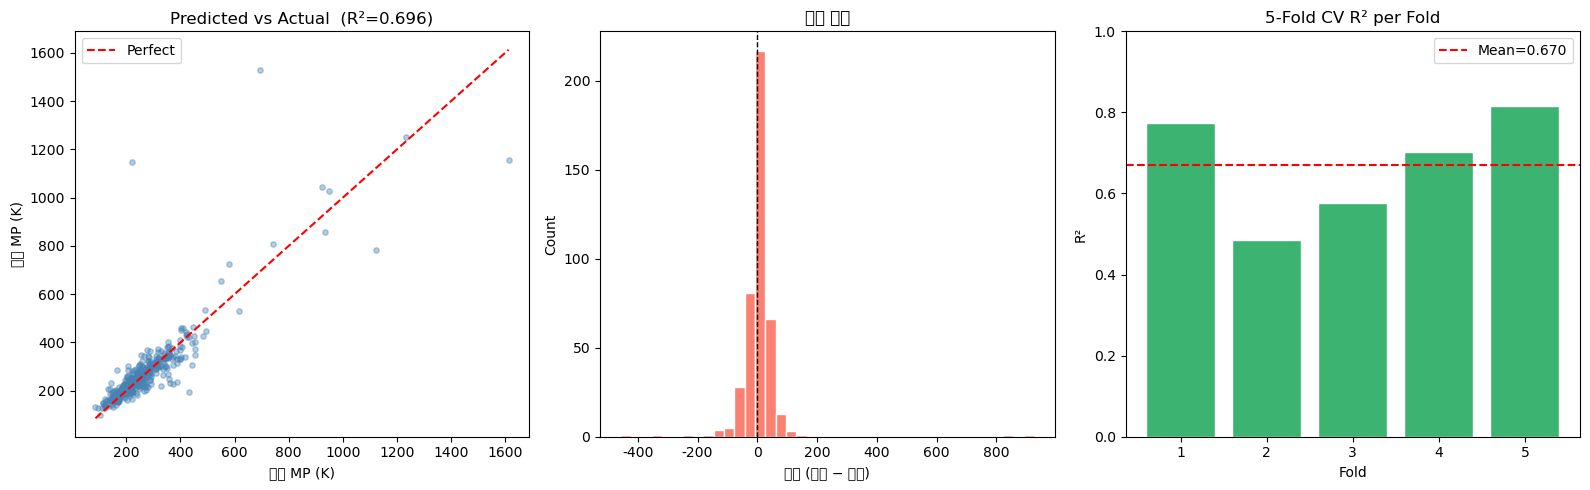

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.4, s=15, color="steelblue")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect")
ax.set_xlabel("실제 MP (K)")
ax.set_ylabel("예측 MP (K)")
ax.set_title(f"Predicted vs Actual  (R²={test_r2:.3f})")
ax.legend()

ax = axes[1]
residuals = y_pred - y_test
ax.hist(residuals, bins=40, color="salmon", edgecolor="white")
ax.axvline(0, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("잔차 (예측 − 실제)")
ax.set_ylabel("Count")
ax.set_title("잔차 분포")

ax = axes[2]
ax.bar(range(1, 6), cv_r2, color="mediumseagreen", edgecolor="white")
ax.axhline(np.mean(cv_r2), color="red", linestyle="--", label=f"Mean={np.mean(cv_r2):.3f}")
ax.set_xlabel("Fold")
ax.set_ylabel("R²")
ax.set_title("5-Fold CV R² per Fold")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

## 10. 결과 요약 — v3 대비 비교

In [12]:
summary = pd.DataFrame({
    "버전": ["base (XGBoost)", "v3_ann (MLP)", "v4_ann (5단계 파이프라인)"],
    "CV R²": ["0.5346", "0.7065", f"{np.mean(cv_r2):.4f}"],
    "CV 편차": ["±0.079", "±0.120", f"±{np.std(cv_r2):.4f}"],
    "Test R²": ["0.4831", "0.5821", f"{test_r2:.4f}"],
    "Test MAE": ["53.06", "46.35", f"{test_mae:.2f}"],
    "CV-Test 갭": ["0.052", "0.124", f"{np.mean(cv_r2) - test_r2:.4f}"],
})
print("=== 버전별 비교 ===")
print(f"노트북 전체 소요: {(time.time()-T0)/60:.1f}분")
summary

=== 버전별 비교 ===
노트북 전체 소요: 0.5분


,버전,CV R²,CV 편차,Test R²,Test MAE,CV-Test 갭
0,base (XGBoost),0.5346,±0.079,0.4831,53.06,0.052
1,v3_ann (MLP),0.7065,±0.120,0.5821,46.35,0.124
2,v4_ann (5단계 파이프라인),0.6702,±0.1235,0.6958,32.53,-0.0256
